# Traffic-Light Synchronization + K-Means (Unsupervised)

## Runtime note (VS Code / macOS)
Before running this notebook, start Jupyter from a terminal where you ran:

```bash
conda activate base
```

If your base environment is missing dependencies, install them once with:

```bash
conda install -y numpy pandas matplotlib scikit-learn
```

This keeps imports (NumPy / pandas / scikit-learn) consistent with your base environment.

---

## Scenario
- Light A cycle: 60s (30s green, 30s red)
- Light B cycle: 90s
- Light C cycle: 120s
They all turn green **together** at 8:00 AM (t = 0 seconds).

### What we compute
1. Next time (minutes from start) when **all three** lights turn green together again.
2. All times within an $8$-hour window when **exactly two** lights (but not all three) turn green together.
3. A big-data style simulation + **K-Means** clustering to *discover/predict* synchronization regimes, then estimate accuracy vs known ground truth (post-hoc).

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from traffic_sync import (
    dual_sync_times_minutes,
    lcm_all,
    next_triple_sync_minutes,
    phase_features,
    sync_count_truth,
 )

# Optional: quick dependency sanity check
try:
    import sklearn
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.metrics import adjusted_rand_score
    print("scikit-learn:", sklearn.__version__)
except Exception as e:
    print("scikit-learn not available in this environment:", e)
    print("If needed, install in base env: conda install scikit-learn")

scikit-learn: 1.7.2


In [2]:
# Original variable names for the inputs
signal_cycles_sec = [60, 90, 120]
monitor_hours = 8

total_seconds = monitor_hours * 3600
minute = 60

print("cycles (sec):", signal_cycles_sec)
print("monitor window (sec):", total_seconds)
print("monitor window (min):", total_seconds / minute)

cycles (sec): [60, 90, 120]
monitor window (sec): 28800
monitor window (min): 480.0


## Ground-truth math (exact)
All three signals “turn green together again” when time $t$ hits a common cycle boundary.
That happens at the least common multiple (LCM) of the cycle lengths:

$$T_{triple}=\mathrm{lcm}(c_1,c_2,c_3)$$

Convert seconds to minutes with $T_{min}=T_{triple}/60$.

For “exactly two” simultaneous green-onsets within a window, we look for times $t$ where exactly two of the conditions $(t \bmod c_i = 0)$ are true.

In [3]:
from functools import reduce
from math import gcd

def lcm_pair(a: int, b: int) -> int:
    a = int(a)
    b = int(b)
    if a <= 0 or b <= 0:
        raise ValueError("cycle lengths must be positive integers")
    return a // gcd(a, b) * b

def lcm_reduce(cadence_list):
    if len(cadence_list) < 2:
        raise ValueError("need at least two cycles")
    return reduce(lcm_pair, [int(x) for x in cadence_list])

def next_triple_sync_minutes(cadence_list) -> float:
    """Minutes from start to the next triple green-onset (excluding t=0)."""
    lcm_all_sec = lcm_reduce(cadence_list)
    return lcm_all_sec / 60.0

In [4]:
def dual_sync_times_minutes(cadence_list, duration_hours: int):
    """All times (minutes) where exactly two signals turn green together.

    We model a green-onset at time t when: t % cycle == 0.
    Exactly-two means the divisibility count across the 3 cycles is 2.
    """
    if len(cadence_list) != 3:
        raise ValueError("this function expects exactly 3 cycles")
    if int(duration_hours) <= 0:
        raise ValueError("duration_hours must be positive")

    horizon_sec = int(duration_hours) * 3600
    cycles = np.array([int(x) for x in cadence_list], dtype=np.int64)
    if np.any(cycles <= 0):
        raise ValueError("cycle lengths must be positive")

    tick_sec = np.arange(0, horizon_sec + 1, dtype=np.int64)
    is_boundary = (tick_sec[:, None] % cycles[None, :]) == 0
    boundary_count = is_boundary.sum(axis=1)

    dual_mask = (boundary_count == 2) & (tick_sec > 0)
    dual_ticks = tick_sec[dual_mask]
    return (dual_ticks.astype(np.float64) / 60.0).tolist()

In [5]:
triple_min = next_triple_sync_minutes(signal_cycles_sec)
dual_minutes = dual_sync_times_minutes(signal_cycles_sec, monitor_hours)

print("Next triple synchronization (minutes):", triple_min)
print("Exactly-dual sync times within 8 hours (count):", len(dual_minutes))
print("First 25 dual times (minutes):", dual_minutes[:25])

# A couple of quick correctness checks
assert triple_min == (lcm_reduce(signal_cycles_sec) / 60.0)
assert all((m * 60) % lcm_reduce(signal_cycles_sec) != 0 for m in dual_minutes)
assert all(m > 0 for m in dual_minutes)

Next triple synchronization (minutes): 6.0
Exactly-dual sync times within 8 hours (count): 240
First 25 dual times (minutes): [2.0, 3.0, 4.0, 8.0, 9.0, 10.0, 14.0, 15.0, 16.0, 20.0, 21.0, 22.0, 26.0, 27.0, 28.0, 32.0, 33.0, 34.0, 38.0, 39.0, 40.0, 44.0, 45.0, 46.0, 50.0]


In [6]:
# --- Big data simulation table (1-second resolution) ---
expanded_hours = 24 * 30  # 30 days
expanded_seconds = expanded_hours * 3600

boulevard_ticks_sec = np.arange(0, expanded_seconds + 1, dtype=np.int64)
cycle_A, cycle_B, cycle_C = [int(x) for x in signal_cycles_sec]

rA = boulevard_ticks_sec % cycle_A
rB = boulevard_ticks_sec % cycle_B
rC = boulevard_ticks_sec % cycle_C

sync_count = (rA == 0).astype(np.int8) + (rB == 0).astype(np.int8) + (rC == 0).astype(np.int8)

# Optional small sensor jitter (keeps ground truth separate)
rng = np.random.default_rng(2026)
jitter_sec = rng.integers(-1, 2, size=boulevard_ticks_sec.size, dtype=np.int8)
observed_tick_sec = boulevard_ticks_sec + jitter_sec

traffic_df = pd.DataFrame({
    "tick_sec": boulevard_ticks_sec,
    "observed_tick_sec": observed_tick_sec,
    "rA": rA.astype(np.int32),
    "rB": rB.astype(np.int32),
    "rC": rC.astype(np.int32),
    "sync_count_truth": sync_count.astype(np.int8),
})

display(traffic_df.head())
print(traffic_df["sync_count_truth"].value_counts().sort_index())

,tick_sec,observed_tick_sec,rA,rB,rC,sync_count_truth
0,0,0,0,0,0,3
1,1,2,1,1,1,0
2,2,1,2,2,2,0
3,3,4,3,3,3,0
4,4,3,4,4,4,0


sync_count_truth
0    2534400
1      28800
2      21600
3       7201
Name: count, dtype: int64


In [7]:
def build_phase_matrix(tick_vector_sec: np.ndarray, cycles_sec):
    """Feature matrix: cyclic phase (cos/sin) for each signal."""
    tick_vector_sec = np.asarray(tick_vector_sec, dtype=np.float64)
    cols = []
    for c in cycles_sec:
        c = float(c)
        angle = 2.0 * np.pi * tick_vector_sec / c
        cols.append(np.cos(angle))
        cols.append(np.sin(angle))
    return np.column_stack(cols)

def majority_vote_cluster_map(cluster_ids: np.ndarray, y_truth: np.ndarray, k: int):
    """Map each cluster to the most common truth label inside it."""
    mapping = {}
    for cid in range(k):
        members = y_truth[cluster_ids == cid]
        if members.size == 0:
            # fallback: global most common
            values, counts = np.unique(y_truth, return_counts=True)
            mapping[cid] = int(values[np.argmax(counts)])
        else:
            values, counts = np.unique(members, return_counts=True)
            mapping[cid] = int(values[np.argmax(counts)])
    return mapping

def kmeans_accuracy_report(hours_to_sim: int, k: int = 4, sample_cap: int = 200_000, seed: int = 7):
    horizon = int(hours_to_sim) * 3600
    ticks = np.arange(0, horizon + 1, dtype=np.int64)

    # build truth labels on the *true* tick, cluster on the (slightly noisy) observed tick
    a, b, c = [int(x) for x in signal_cycles_sec]
    remA = ticks % a
    remB = ticks % b
    remC = ticks % c
    y_truth = ((remA == 0).astype(np.int8) + (remB == 0).astype(np.int8) + (remC == 0).astype(np.int8)).astype(np.int64)

    local_rng = np.random.default_rng(seed + int(hours_to_sim))
    jitter = local_rng.integers(-1, 2, size=ticks.size, dtype=np.int8)
    observed = ticks + jitter

    # Subsample for speed (still reflects the expanded window)
    if ticks.size > sample_cap:
        pick_idx = local_rng.choice(ticks.size, size=sample_cap, replace=False)
        observed = observed[pick_idx]
        y_truth = y_truth[pick_idx]

    X = build_phase_matrix(observed, signal_cycles_sec)

    km = KMeans(n_clusters=k, n_init="auto", random_state=seed)
    cluster_ids = km.fit_predict(X)

    cluster_map = majority_vote_cluster_map(cluster_ids, y_truth, k=k)
    y_pred = np.array([cluster_map[int(cid)] for cid in cluster_ids], dtype=np.int64)

    overall_acc = float((y_pred == y_truth).mean())
    ari = float(adjusted_rand_score(y_truth, cluster_ids))

    dual_acc = float((y_pred[y_truth == 2] == 2).mean()) if np.any(y_truth == 2) else float("nan")
    triple_acc = float((y_pred[y_truth == 3] == 3).mean()) if np.any(y_truth == 3) else float("nan")

    return {
        "hours": int(hours_to_sim),
        "n_used": int(y_truth.size),
        "k": int(k),
        "overall_accuracy": overall_acc,
        "ARI": ari,
        "accuracy_dual(class=2)": dual_acc,
        "accuracy_triple(class=3)": triple_acc,
    }

/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/h

,hours,n_used,k,overall_accuracy,ARI,accuracy_dual(class=2),accuracy_triple(class=3)
0,8,28801,4,0.977744,0.000196,0.0,0.0
1,24,86401,4,0.977766,0.000243,0.0,0.0
2,168,200000,4,0.977640,0.000266,0.0,0.0
3,720,200000,4,0.977440,0.000314,0.0,0.0


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/h

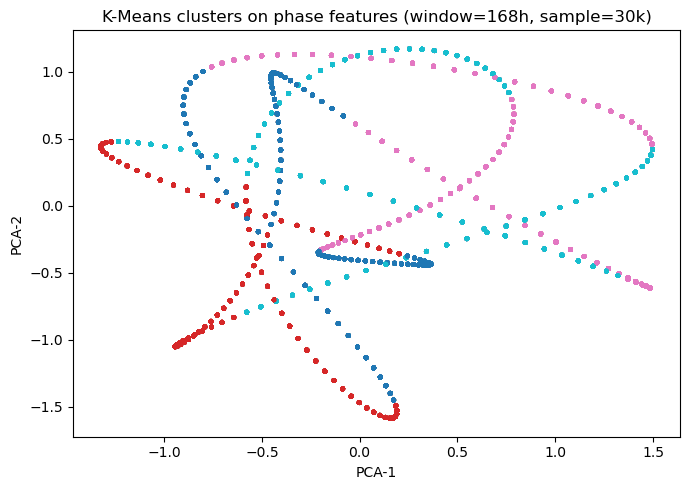

Cluster sizes:
0    7843
1    7435
2    7564
3    7158
Name: count, dtype: int64


In [8]:
expansion_hours_list = [8, 24, 24 * 7, 24 * 30]
k_clusters = 4

rows = []
for h in expansion_hours_list:
    rows.append(kmeans_accuracy_report(h, k=k_clusters, sample_cap=200_000, seed=11))

score_df = pd.DataFrame(rows)
display(score_df)

# Quick cluster visualization on one window (PCA -> 2D)
viz_hours = 24 * 7
viz_horizon = viz_hours * 3600
viz_ticks = np.arange(0, viz_horizon + 1, dtype=np.int64)
viz_rng = np.random.default_rng(123)
viz_idx = viz_rng.choice(viz_ticks.size, size=30_000, replace=False)

viz_observed = viz_ticks[viz_idx] + viz_rng.integers(-1, 2, size=viz_idx.size, dtype=np.int8)
viz_X = build_phase_matrix(viz_observed, signal_cycles_sec)

viz_km = KMeans(n_clusters=k_clusters, n_init="auto", random_state=11)
viz_cluster = viz_km.fit_predict(viz_X)

pca = PCA(n_components=2, random_state=11)
proj = pca.fit_transform(viz_X)

plt.figure(figsize=(7, 5))
plt.scatter(proj[:, 0], proj[:, 1], c=viz_cluster, s=6, cmap="tab10")
plt.title(f"K-Means clusters on phase features (window={viz_hours}h, sample=30k)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.tight_layout()
plt.show()

print("Cluster sizes:")
print(pd.Series(viz_cluster).value_counts().sort_index())

In [9]:
%%writefile traffic_sync.py
"""Reusable traffic-signal synchronization helpers.

Generated/updated from the notebook so you can re-import cleanly.
"""

from __future__ import annotations

from functools import reduce
from math import gcd, pi
from typing import List, Sequence

import numpy as np


def lcm_pair(a: int, b: int) -> int:
    a = int(a)
    b = int(b)
    if a <= 0 or b <= 0:
        raise ValueError("cycle lengths must be positive integers")
    return a // gcd(a, b) * b


def lcm_all(cycle_lengths: Sequence[int]) -> int:
    if not cycle_lengths:
        raise ValueError("cycle_lengths must be non-empty")
    return reduce(lcm_pair, [int(x) for x in cycle_lengths])


def next_triple_sync_minutes(cycle_lengths_sec: Sequence[int]) -> float:
    """Minutes until the next triple alignment (t>0)."""
    return lcm_all(cycle_lengths_sec) / 60.0


def dual_sync_times_minutes(cycle_lengths_sec: Sequence[int], duration_hours: int) -> List[float]:
    """Times (minutes) when exactly two signals align within the window."""
    if len(cycle_lengths_sec) != 3:
        raise ValueError("expected exactly three cycle lengths")
    horizon = int(duration_hours) * 3600
    cycles = np.array([int(x) for x in cycle_lengths_sec], dtype=np.int64)
    ticks = np.arange(0, horizon + 1, dtype=np.int64)
    is_boundary = (ticks[:, None] % cycles[None, :]) == 0
    count = is_boundary.sum(axis=1)
    dual_ticks = ticks[(count == 2) & (ticks > 0)]
    return (dual_ticks.astype(np.float64) / 60.0).tolist()


def sync_count_truth(ticks_sec: np.ndarray, cycle_lengths_sec: Sequence[int]) -> np.ndarray:
    cycles = np.array([int(x) for x in cycle_lengths_sec], dtype=np.int64)
    ticks_sec = np.asarray(ticks_sec, dtype=np.int64)
    return ((ticks_sec[:, None] % cycles[None, :]) == 0).sum(axis=1)


def phase_features(ticks_sec: np.ndarray, cycle_lengths_sec: Sequence[int]) -> np.ndarray:
    ticks = np.asarray(ticks_sec, dtype=np.float64)
    cols = []
    for c in cycle_lengths_sec:
        c = float(c)
        theta = (2.0 * pi * ticks) / c
        cols.append(np.cos(theta))
        cols.append(np.sin(theta))
    return np.column_stack(cols)

Overwriting traffic_sync.py


In [10]:
import importlib
import traffic_sync as ts
importlib.reload(ts)

print("Module triple sync (min):", ts.next_triple_sync_minutes(signal_cycles_sec))
print("Module dual sync count:", len(ts.dual_sync_times_minutes(signal_cycles_sec, monitor_hours)))

Module triple sync (min): 6.0
Module dual sync count: 240


In [11]:
import time

def dual_sync_times_minutes_slow(cadence_list, duration_hours: int):
    horizon_sec = int(duration_hours) * 3600
    a, b, c = [int(x) for x in cadence_list]
    out = []
    for t in range(1, horizon_sec + 1):
        hits = int(t % a == 0) + int(t % b == 0) + int(t % c == 0)
        if hits == 2:
            out.append(t / 60.0)
    return out

bench_hours = 24  # 1 day bench
t0 = time.perf_counter()
fast_out = dual_sync_times_minutes(signal_cycles_sec, bench_hours)
t1 = time.perf_counter()
slow_out = dual_sync_times_minutes_slow(signal_cycles_sec, bench_hours)
t2 = time.perf_counter()

print(f"Vectorized dual-sync: {t1 - t0:.4f}s (n={len(fast_out)})")
print(f"Python-loop dual-sync: {t2 - t1:.4f}s (n={len(slow_out)})")
assert fast_out == slow_out

Vectorized dual-sync: 0.0037s (n=720)
Python-loop dual-sync: 0.0126s (n=720)


## Interpretation
- The LCM-based result is **exact** for the next triple green-onset: it’s pure number theory.
- The “exactly two” list is also exact because it’s just counting divisibility events ($t \bmod c_i=0$).
- K-Means here is **exploratory**: we feed it cyclic phase features and then evaluate how well clusters align with the known synchronization count (0..3).
- The reported “accuracy” is computed *after the fact* by mapping each cluster to the most common ground-truth label in that cluster (majority vote).

If you change the cycles (or add noise/jitter), you’ll see the clustering accuracy and ARI respond as the data expands (more hours ⇒ more repeated structure).